# Experiment 1-3: Deduplication Analysis with CVE Balancing

This notebook performs the deduplication experiment as specified:
1. Process Juliet C SimHash datasets (k=1 to k=12) with CVE balancing
2. Process Devign dataset with class balancing only (no CVE balancing)
3. Save all metadata and verify results
4. Experiment 1 = aixcoder Experiment 2 = deepseek Experiment 3 = codellama




All outputs are saved to `tensors/Experiment_k/`

## 1. Import Required Libraries

In [1]:
import sys
sys.path.insert(0, '/Users/aeg00011/Romeo')

# Force reimport of preprocessing module to ensure latest changes are used
import importlib
if 'preprocessing' in sys.modules:
    del sys.modules['preprocessing']

# Import preprocessing module
from preprocessing import (
    preprocess_data
)

# Other required imports
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from transformers import AutoTokenizer
import os
import json
import datetime
import shutil

print("All imports successful!")
print(f"Experiment started at: {datetime.datetime.now().isoformat()}")

Preprocessing functions defined successfully!
All imports successful!
Experiment started at: 2026-02-26T09:51:24.979693


## 2. Initialize Tokenizer



In [2]:
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B-Instruct")
print(f"Tokenizer loaded: {tokenizer.__class__.__name__}")
print(f"Vocab size: {tokenizer.vocab_size}")
print("Loaded tokenizer size:", len(tokenizer))
print(f"Model max length: {tokenizer.model_max_length}")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: Qwen2TokenizerFast
Vocab size: 151643
Loaded tokenizer size: 151665
Model max length: 131072


## 3. Create Experiment Directory

In [3]:
# Define paths
BASE_DIR = '/Users/aeg00011/Romeo'
EXPERIMENT_DIR = os.path.join(BASE_DIR, 'tensors', 'Experiment_5')
SIMHASH_DIR = os.path.join(BASE_DIR, 'simhash_datasets')
DATASETS_DIR = os.path.join(BASE_DIR, 'datasets')

# Create Experiment directory
if os.path.exists(EXPERIMENT_DIR):
    print(f"Warning: {EXPERIMENT_DIR} already exists!")
    response = input("Delete existing directory and start fresh? (yes/no): ")
    if response.lower() == 'yes':
        shutil.rmtree(EXPERIMENT_DIR)
        print("Deleted existing directory.")
    else:
        print("Continuing with existing directory. Some files may be overwritten.")

os.makedirs(EXPERIMENT_DIR, exist_ok=True)
print(f"Experiment directory: {EXPERIMENT_DIR}")

# Verify simhash datasets exist
print(f"\nChecking simhash datasets...")
for k in range(1, 13):
    db_path = os.path.join(SIMHASH_DIR, f'juliet_c_simhash_k={k}.db')
    exists = os.path.exists(db_path)
    status = "✓" if exists else "✗"
    print(f"  {status} k={k}: {os.path.basename(db_path)}")

# Verify devign dataset exists
devign_path = os.path.join(DATASETS_DIR, 'devign.db')
devign_exists = os.path.exists(devign_path)
status = "✓" if devign_exists else "✗"
print(f"  {status} Devign: {os.path.basename(devign_path)}")

Experiment directory: /Users/aeg00011/Romeo/tensors/Experiment_5

Checking simhash datasets...
  ✓ k=1: juliet_c_simhash_k=1.db
  ✓ k=2: juliet_c_simhash_k=2.db
  ✓ k=3: juliet_c_simhash_k=3.db
  ✓ k=4: juliet_c_simhash_k=4.db
  ✓ k=5: juliet_c_simhash_k=5.db
  ✓ k=6: juliet_c_simhash_k=6.db
  ✓ k=7: juliet_c_simhash_k=7.db
  ✓ k=8: juliet_c_simhash_k=8.db
  ✓ k=9: juliet_c_simhash_k=9.db
  ✓ k=10: juliet_c_simhash_k=10.db
  ✓ k=11: juliet_c_simhash_k=11.db
  ✓ k=12: juliet_c_simhash_k=12.db
  ✓ Devign: devign.db


## 4. Process Juliet C SimHash Datasets (k=1 to k=12)

In [4]:
# Configuration for Juliet C datasets
# Note: max_tokens filters out functions longer than this threshold
#       max_seq_length is the final padded/truncated tensor length
#       Using preprocessing.py defaults: MIN_TOKENS=32, MAX_TOKENS=4096

JULIET_CONFIG = {
    'limit_per_class': 200000,
    'balance_classes': True,
    'balance_cve': True,
    'random_state': 42,
    'min_tokens': 32,       # Functions shorter than this are excluded
    'max_tokens': 4096,     # Functions longer than this are excluded
    'max_seq_length': 4096  # Tensor output length (should match max_tokens)
}

print("Juliet C Processing Configuration:")
for key, value in JULIET_CONFIG.items():
    print(f"  {key}: {value}")
print(f"\nNote: max_tokens=max_seq_length means no truncation needed (already filtered)")

Juliet C Processing Configuration:
  limit_per_class: 200000
  balance_classes: True
  balance_cve: True
  random_state: 42
  min_tokens: 32
  max_tokens: 4096
  max_seq_length: 4096

Note: max_tokens=max_seq_length means no truncation needed (already filtered)


In [5]:
# Process each Juliet C simhash dataset
juliet_results = {}
juliet_errors = []

for k in range(1, 13):
    print(f"\n{'='*80}")
    print(f"Processing Juliet C SimHash k={k}")
    print(f"{'='*80}")
    
    db_path = os.path.join(SIMHASH_DIR, f'juliet_c_simhash_k={k}.db')
    dataset_name = f'juliet_c_simhash_k={k}'
    
    try:
        stats = preprocess_data(
            db_path=db_path,
            tokenizer=tokenizer,
            limit_per_class=JULIET_CONFIG['limit_per_class'],
            balance_classes=JULIET_CONFIG['balance_classes'],
            balance_cve=JULIET_CONFIG['balance_cve'],
            random_state=JULIET_CONFIG['random_state'],
            min_tokens=JULIET_CONFIG['min_tokens'],
            max_tokens=JULIET_CONFIG['max_tokens'],
            max_seq_length=JULIET_CONFIG['max_seq_length'],
            output_dir=EXPERIMENT_DIR,
            dataset_name=dataset_name
        )
        
        juliet_results[k] = stats
        print(f"\n✓ Successfully processed k={k}")
        print(f"  Total samples: {stats['total_samples']}")
        print(f"  Train/Val/Test: {stats['train_size']}/{stats['val_size']}/{stats['test_size']}")
        print(f"  CWEs represented: {stats['num_cwes']}")
        
    except Exception as e:
        print(f"\n✗ Error processing k={k}: {str(e)}")
        juliet_errors.append({'k': k, 'error': str(e)})

print(f"\n{'='*80}")
print(f"Juliet C Processing Complete")
print(f"{'='*80}")
print(f"Successfully processed: {len(juliet_results)}/12 datasets")
if juliet_errors:
    print(f"Errors: {len(juliet_errors)}")
    for err in juliet_errors:
        print(f"  k={err['k']}: {err['error']}")


Processing Juliet C SimHash k=1
Loading data from /Users/aeg00011/Romeo/simhash_datasets/juliet_c_simhash_k=1.db...
Applying CVE-balanced sampling...
  Vulnerable samples span 110 CVEs
  Non-vulnerable samples span 113 CVEs
  After balancing: 12185 vulnerable, 9830 non-vulnerable
  CVEs represented: 110 (vuln), 113 (non-vuln)
Loaded: 12185 vulnerable, 9830 non-vulnerable
Total unique CWEs: 114

Dataset: 12185 positive (55.3%), 9830 negative (44.7%)

Split sizes: Train=15410, Val=4425, Test=2180
Positive %: Train=55.3%, Val=55.9%, Test=54.3%

Tokenizing...
Processing sample 1/15410...
Processing sample 1001/15410...
Processing sample 2001/15410...
Processing sample 3001/15410...
Processing sample 4001/15410...
Processing sample 5001/15410...
Processing sample 6001/15410...
Processing sample 7001/15410...
Processing sample 8001/15410...
Processing sample 9001/15410...
Processing sample 10001/15410...
Processing sample 11001/15410...
Processing sample 12001/15410...
Processing sample 130

## 5. Process Devign Dataset (With Train/Val/Test split)

In [6]:
# Configuration for Devign dataset (NO CVE balancing)
# Using same token settings as Juliet for consistency

DEVIGN_CONFIG = {
    'limit_per_class': 200000,
    'balance_classes': True,
    'balance_cve': False,  # NO CVE balancing for Devign
    'random_state': 42,
    'min_tokens': 32,       # Functions shorter than this are excluded
    'max_tokens': 4096,     # Functions longer than this are excluded  
    'max_seq_length': 4096  # Tensor output length (should match max_tokens)
}

print("Devign Processing Configuration:")
for key, value in DEVIGN_CONFIG.items():
    print(f"  {key}: {value}")

Devign Processing Configuration:
  limit_per_class: 200000
  balance_classes: True
  balance_cve: False
  random_state: 42
  min_tokens: 32
  max_tokens: 4096
  max_seq_length: 4096


In [7]:
# Process Devign dataset
print(f"\n{'='*80}")
print(f"Processing Devign Dataset")
print(f"{'='*80}")

devign_path = os.path.join(DATASETS_DIR, 'devign.db')
devign_result = None
devign_error = None

try:
    devign_result = preprocess_data(
        db_path=devign_path,
        tokenizer=tokenizer,
        limit_per_class=DEVIGN_CONFIG['limit_per_class'],
        balance_classes=DEVIGN_CONFIG['balance_classes'],
        balance_cve=DEVIGN_CONFIG['balance_cve'],
        random_state=DEVIGN_CONFIG['random_state'],
        min_tokens=DEVIGN_CONFIG['min_tokens'],
        max_tokens=DEVIGN_CONFIG['max_tokens'],
        max_seq_length=DEVIGN_CONFIG['max_seq_length'],
        output_dir=EXPERIMENT_DIR,
        dataset_name='devign'
    )
    
    print(f"\n✓ Successfully processed Devign")
    print(f"  Total samples: {devign_result['total_samples']}")
    print(f"  Vulnerable: {devign_result['vulnerable']}")
    print(f"  Non-vulnerable: {devign_result['non_vulnerable']}")
    print(f"  Train/Val/Test: {devign_result['train_size']}/{devign_result['val_size']}/{devign_result['test_size']}")
    
    # Calculate and display class ratio
    pos_ratio = devign_result['vulnerable'] / devign_result['total_samples'] * 100
    neg_ratio = devign_result['non_vulnerable'] / devign_result['total_samples'] * 100
    print(f"  Positive/Negative ratio: {pos_ratio:.1f}% / {neg_ratio:.1f}%")
    
except Exception as e:
    print(f"\n✗ Error processing Devign: {str(e)}")
    devign_error = str(e)


Processing Devign Dataset
Loading data from /Users/aeg00011/Romeo/datasets/devign.db...
Loaded: 12071 vulnerable, 12071 non-vulnerable
Total unique CWEs: 1

Dataset: 12071 positive (50.0%), 12071 negative (50.0%)

Split sizes: Train=16899, Val=4852, Test=2391
Positive %: Train=50.0%, Val=49.2%, Test=51.7%

Tokenizing...
Processing sample 1/16899...


KeyboardInterrupt: 

## 5.5 Create Full Devign Dataset (No Splitting)

This creates the complete Devign dataset without train/val/test splitting for use as an out-of-distribution (OOD) evaluation set.

In [8]:
# Configuration for Full Devign dataset (OOD evaluation)
# Same settings as split version, but with full_dataset_mode=True

DEVIGN_FULL_CONFIG = {
    'limit_per_class': 200000,
    'balance_classes': True,
    'balance_cve': False,  # NO CVE balancing for Devign
    'random_state': 42,
    'min_tokens': 32,
    'max_tokens': 4096,
    'max_seq_length': 4096,
    'full_dataset_mode': True  # Creates single dataset without splits
}

print("Full Devign (OOD) Processing Configuration:")
for key, value in DEVIGN_FULL_CONFIG.items():
    print(f"  {key}: {value}")

Full Devign (OOD) Processing Configuration:
  limit_per_class: 200000
  balance_classes: True
  balance_cve: False
  random_state: 42
  min_tokens: 32
  max_tokens: 4096
  max_seq_length: 4096
  full_dataset_mode: True


In [9]:
# Process Full Devign dataset (for OOD evaluation)
print(f"\n{'='*80}")
print(f"Processing Full Devign Dataset (OOD Evaluation Set)")
print(f"{'='*80}")

devign_path = os.path.join(DATASETS_DIR, 'devign.db')
devign_full_result = None
devign_full_error = None

try:
    devign_full_result = preprocess_data(
        db_path=devign_path,
        tokenizer=tokenizer,
        limit_per_class=DEVIGN_FULL_CONFIG['limit_per_class'],
        balance_classes=DEVIGN_FULL_CONFIG['balance_classes'],
        balance_cve=DEVIGN_FULL_CONFIG['balance_cve'],
        random_state=DEVIGN_FULL_CONFIG['random_state'],
        min_tokens=DEVIGN_FULL_CONFIG['min_tokens'],
        max_tokens=DEVIGN_FULL_CONFIG['max_tokens'],
        max_seq_length=DEVIGN_FULL_CONFIG['max_seq_length'],
        output_dir=EXPERIMENT_DIR,
        dataset_name='devign_ood',
        full_dataset_mode=DEVIGN_FULL_CONFIG['full_dataset_mode']
    )
    
    print(f"\n✓ Successfully processed Full Devign (OOD)")
    print(f"  Total samples: {devign_full_result['total_samples']}")
    print(f"  Full dataset size: {devign_full_result['full_size']}")
    print(f"  Vulnerable: {devign_full_result['vulnerable']}")
    print(f"  Non-vulnerable: {devign_full_result['non_vulnerable']}")
    
    # Calculate and display class ratio
    pos_ratio = devign_full_result['vulnerable'] / devign_full_result['total_samples'] * 100
    neg_ratio = devign_full_result['non_vulnerable'] / devign_full_result['total_samples'] * 100
    print(f"  Positive/Negative ratio: {pos_ratio:.1f}% / {neg_ratio:.1f}%")
    print(f"  Output files: full_sequences.pt, full_labels.pt, full_cwe_indices.pt")
    
except Exception as e:
    print(f"\n✗ Error processing Full Devign: {str(e)}")
    devign_full_error = str(e)


Processing Full Devign Dataset (OOD Evaluation Set)
Loading data from /Users/aeg00011/Romeo/datasets/devign.db...
Loaded: 12071 vulnerable, 12071 non-vulnerable
Total unique CWEs: 1

Dataset: 12071 positive (50.0%), 12071 negative (50.0%)

Full dataset mode: skipping train/val/test split...
Tokenizing...
Processing sample 1/24142...
Processing sample 1001/24142...
Processing sample 2001/24142...
Processing sample 3001/24142...
Processing sample 4001/24142...
Processing sample 5001/24142...
Processing sample 6001/24142...
Processing sample 7001/24142...
Processing sample 8001/24142...
Processing sample 9001/24142...
Processing sample 10001/24142...
Processing sample 11001/24142...
Processing sample 12001/24142...
Processing sample 13001/24142...
Processing sample 14001/24142...
Processing sample 15001/24142...
Processing sample 16001/24142...
Processing sample 17001/24142...
Processing sample 18001/24142...
Processing sample 19001/24142...
Processing sample 20001/24142...
Processing sa

## 6. Verify All Datasets Were Created

In [10]:
# List all subdirectories in Experiment folder
print(f"\nDatasets in {EXPERIMENT_DIR}:")
print("="*80)

created_datasets = []
for item in sorted(os.listdir(EXPERIMENT_DIR)):
    item_path = os.path.join(EXPERIMENT_DIR, item)
    if os.path.isdir(item_path):
        # Calculate folder size
        total_size = 0
        file_count = 0
        for f in os.listdir(item_path):
            fp = os.path.join(item_path, f)
            if os.path.isfile(fp):
                total_size += os.path.getsize(fp)
                file_count += 1
        
        size_mb = total_size / (1024 * 1024)
        print(f"  {item}")
        print(f"    Files: {file_count}, Size: {size_mb:.2f} MB")
        created_datasets.append(item)

print(f"\nTotal datasets created: {len(created_datasets)}")
expected_count = 13  # 12 Juliet + 1 Devign
if len(created_datasets) == expected_count:
    print(f"✓ All {expected_count} datasets created successfully!")
else:
    print(f"✗ Expected {expected_count} datasets, found {len(created_datasets)}")


Datasets in /Users/aeg00011/Romeo/tensors/Experiment_5:
  devign_20260226_095522_seed42
    Files: 0, Size: 0.00 MB
  devign_ood_20260226_095600_seed42
    Files: 6, Size: 754.81 MB
  juliet_c_simhash_k=10_20260226_095336_seed42
    Files: 12, Size: 28.97 MB
  juliet_c_simhash_k=11_20260226_095337_seed42
    Files: 12, Size: 20.28 MB
  juliet_c_simhash_k=12_20260226_095338_seed42
    Files: 12, Size: 13.43 MB
  juliet_c_simhash_k=1_20260226_095224_seed42
    Files: 12, Size: 688.33 MB
  juliet_c_simhash_k=2_20260226_095246_seed42
    Files: 12, Size: 521.03 MB
  juliet_c_simhash_k=3_20260226_095302_seed42
    Files: 12, Size: 395.84 MB
  juliet_c_simhash_k=4_20260226_095313_seed42
    Files: 12, Size: 283.97 MB
  juliet_c_simhash_k=5_20260226_095321_seed42
    Files: 12, Size: 203.03 MB
  juliet_c_simhash_k=6_20260226_095327_seed42
    Files: 12, Size: 140.40 MB
  juliet_c_simhash_k=7_20260226_095331_seed42
    Files: 12, Size: 95.10 MB
  juliet_c_simhash_k=8_20260226_095333_seed42
  

## 7. Validate Tensor Shapes and Labels

In [11]:
# Validate each dataset
validation_results = []

print("Validating tensor shapes and labels...")
print("="*80)

for dataset_dir in sorted(created_datasets):
    dataset_path = os.path.join(EXPERIMENT_DIR, dataset_dir)
    result = {'dataset': dataset_dir, 'valid': True, 'errors': []}
    
    try:
        # Load tensors
        train_seq = torch.load(os.path.join(dataset_path, 'train_sequences.pt'), weights_only=True)
        train_labels = torch.load(os.path.join(dataset_path, 'train_labels.pt'), weights_only=True)
        train_cwes = torch.load(os.path.join(dataset_path, 'train_cwe_indices.pt'), weights_only=True)
        
        val_seq = torch.load(os.path.join(dataset_path, 'val_sequences.pt'), weights_only=True)
        val_labels = torch.load(os.path.join(dataset_path, 'val_labels.pt'), weights_only=True)
        val_cwes = torch.load(os.path.join(dataset_path, 'val_cwe_indices.pt'), weights_only=True)
        
        test_seq = torch.load(os.path.join(dataset_path, 'test_sequences.pt'), weights_only=True)
        test_labels = torch.load(os.path.join(dataset_path, 'test_labels.pt'), weights_only=True)
        test_cwes = torch.load(os.path.join(dataset_path, 'test_cwe_indices.pt'), weights_only=True)
        
        # Load CWE mapping
        cwe_to_idx = torch.load(os.path.join(dataset_path, 'cwe_to_idx.pt'), weights_only=False)
        
        # Validate shapes match
        if train_seq.shape[0] != train_labels.shape[0]:
            result['errors'].append(f"Train shape mismatch: seq={train_seq.shape[0]}, labels={train_labels.shape[0]}")
        if val_seq.shape[0] != val_labels.shape[0]:
            result['errors'].append(f"Val shape mismatch: seq={val_seq.shape[0]}, labels={val_labels.shape[0]}")
        if test_seq.shape[0] != test_labels.shape[0]:
            result['errors'].append(f"Test shape mismatch: seq={test_seq.shape[0]}, labels={test_labels.shape[0]}")
        
        # Validate labels are only 0s and 1s
        all_labels = torch.cat([train_labels, val_labels, test_labels])
        unique_labels = torch.unique(all_labels).tolist()
        if set(unique_labels) - {0, 1}:
            result['errors'].append(f"Invalid labels found: {unique_labels}")
        
        # Validate CWE indices are within range
        all_cwes = torch.cat([train_cwes, val_cwes, test_cwes])
        max_cwe_idx = len(cwe_to_idx) - 1
        if all_cwes.max().item() > max_cwe_idx:
            result['errors'].append(f"CWE index out of range: max={all_cwes.max().item()}, expected<={max_cwe_idx}")
        
        result['shapes'] = {
            'train': train_seq.shape,
            'val': val_seq.shape,
            'test': test_seq.shape
        }
        result['num_cwes'] = len(cwe_to_idx)
        result['label_distribution'] = {
            'train_pos': (train_labels == 1).sum().item(),
            'train_neg': (train_labels == 0).sum().item(),
            'test_pos': (test_labels == 1).sum().item(),
            'test_neg': (test_labels == 0).sum().item()
        }
        
    except Exception as e:
        result['errors'].append(f"Load error: {str(e)}")
    
    if result['errors']:
        result['valid'] = False
    
    validation_results.append(result)
    
    # Print result
    status = "✓" if result['valid'] else "✗"
    print(f"{status} {dataset_dir}")
    if 'shapes' in result:
        print(f"    Train: {result['shapes']['train']}")
        print(f"    Val: {result['shapes']['val']}")
        print(f"    Test: {result['shapes']['test']}")
        print(f"    CWEs: {result['num_cwes']}")
    if result['errors']:
        for err in result['errors']:
            print(f"    Error: {err}")

# Summary
valid_count = sum(1 for r in validation_results if r['valid'])
print(f"\nValidation Summary: {valid_count}/{len(validation_results)} datasets valid")

Validating tensor shapes and labels...
✗ devign_20260226_095522_seed42
    Error: Load error: [Errno 2] No such file or directory: '/Users/aeg00011/Romeo/tensors/Experiment_5/devign_20260226_095522_seed42/train_sequences.pt'
✗ devign_ood_20260226_095600_seed42
    Error: Load error: [Errno 2] No such file or directory: '/Users/aeg00011/Romeo/tensors/Experiment_5/devign_ood_20260226_095600_seed42/train_sequences.pt'
✓ juliet_c_simhash_k=10_20260226_095336_seed42
    Train: torch.Size([648, 4096])
    Val: torch.Size([186, 4096])
    Test: torch.Size([92, 4096])
    CWEs: 103
✓ juliet_c_simhash_k=11_20260226_095337_seed42
    Train: torch.Size([453, 4096])
    Val: torch.Size([130, 4096])
    Test: torch.Size([65, 4096])
    CWEs: 94
✓ juliet_c_simhash_k=12_20260226_095338_seed42
    Train: torch.Size([300, 4096])
    Val: torch.Size([86, 4096])
    Test: torch.Size([43, 4096])
    CWEs: 86
✓ juliet_c_simhash_k=1_20260226_095224_seed42
    Train: torch.Size([15410, 4096])
    Val: torch.

## 8. Analyze CWE Distribution Across k Values

In [12]:
# Analyze CWE distribution for each Juliet dataset
cwe_analysis = {}

print("Analyzing CWE distributions across k values...")
print("="*80)

for k in range(1, 13):
    if k not in juliet_results:
        continue
    
    result = juliet_results[k]
    dataset_dir = result['output_dir']
    
    # Load CWE indices
    train_cwes = torch.load(os.path.join(dataset_dir, 'train_cwe_indices.pt'), weights_only=True)
    test_cwes = torch.load(os.path.join(dataset_dir, 'test_cwe_indices.pt'), weights_only=True)
    
    # Compute distribution statistics
    train_dist = Counter(train_cwes.numpy())
    test_dist = Counter(test_cwes.numpy())
    
    train_counts = list(train_dist.values())
    test_counts = list(test_dist.values())
    
    cwe_analysis[k] = {
        'num_cwes_train': len(train_dist),
        'num_cwes_test': len(test_dist),
        'train_mean': np.mean(train_counts),
        'train_std': np.std(train_counts),
        'train_min': min(train_counts),
        'train_max': max(train_counts),
        'test_mean': np.mean(test_counts),
        'test_std': np.std(test_counts),
    }
    
    print(f"k={k}:")
    print(f"  Train - CWEs: {len(train_dist)}, Mean: {np.mean(train_counts):.1f}, Std: {np.std(train_counts):.1f}")
    print(f"  Test  - CWEs: {len(test_dist)}, Mean: {np.mean(test_counts):.1f}, Std: {np.std(test_counts):.1f}")

Analyzing CWE distributions across k values...
k=1:
  Train - CWEs: 114, Mean: 135.2, Std: 115.7
  Test  - CWEs: 107, Mean: 20.4, Std: 16.8
k=2:
  Train - CWEs: 114, Mean: 102.3, Std: 89.2
  Test  - CWEs: 103, Mean: 16.0, Std: 13.0
k=3:
  Train - CWEs: 112, Mean: 79.1, Std: 69.1
  Test  - CWEs: 100, Mean: 12.5, Std: 10.1
k=4:
  Train - CWEs: 110, Mean: 57.8, Std: 49.8
  Test  - CWEs: 96, Mean: 9.4, Std: 7.4
k=5:
  Train - CWEs: 111, Mean: 40.9, Std: 35.4
  Test  - CWEs: 90, Mean: 7.1, Std: 5.4
k=6:
  Train - CWEs: 106, Mean: 29.7, Std: 25.2
  Test  - CWEs: 90, Mean: 4.9, Std: 3.6
k=7:
  Train - CWEs: 104, Mean: 20.5, Std: 16.8
  Test  - CWEs: 78, Mean: 3.9, Std: 2.9
k=8:
  Train - CWEs: 101, Mean: 13.9, Std: 11.3
  Test  - CWEs: 64, Mean: 3.1, Std: 2.1
k=9:
  Train - CWEs: 103, Mean: 9.1, Std: 7.3
  Test  - CWEs: 55, Mean: 2.4, Std: 1.4
k=10:
  Train - CWEs: 93, Mean: 7.0, Std: 5.2
  Test  - CWEs: 50, Mean: 1.8, Std: 1.3
k=11:
  Train - CWEs: 86, Mean: 5.3, Std: 3.8
  Test  - CWEs: 44,

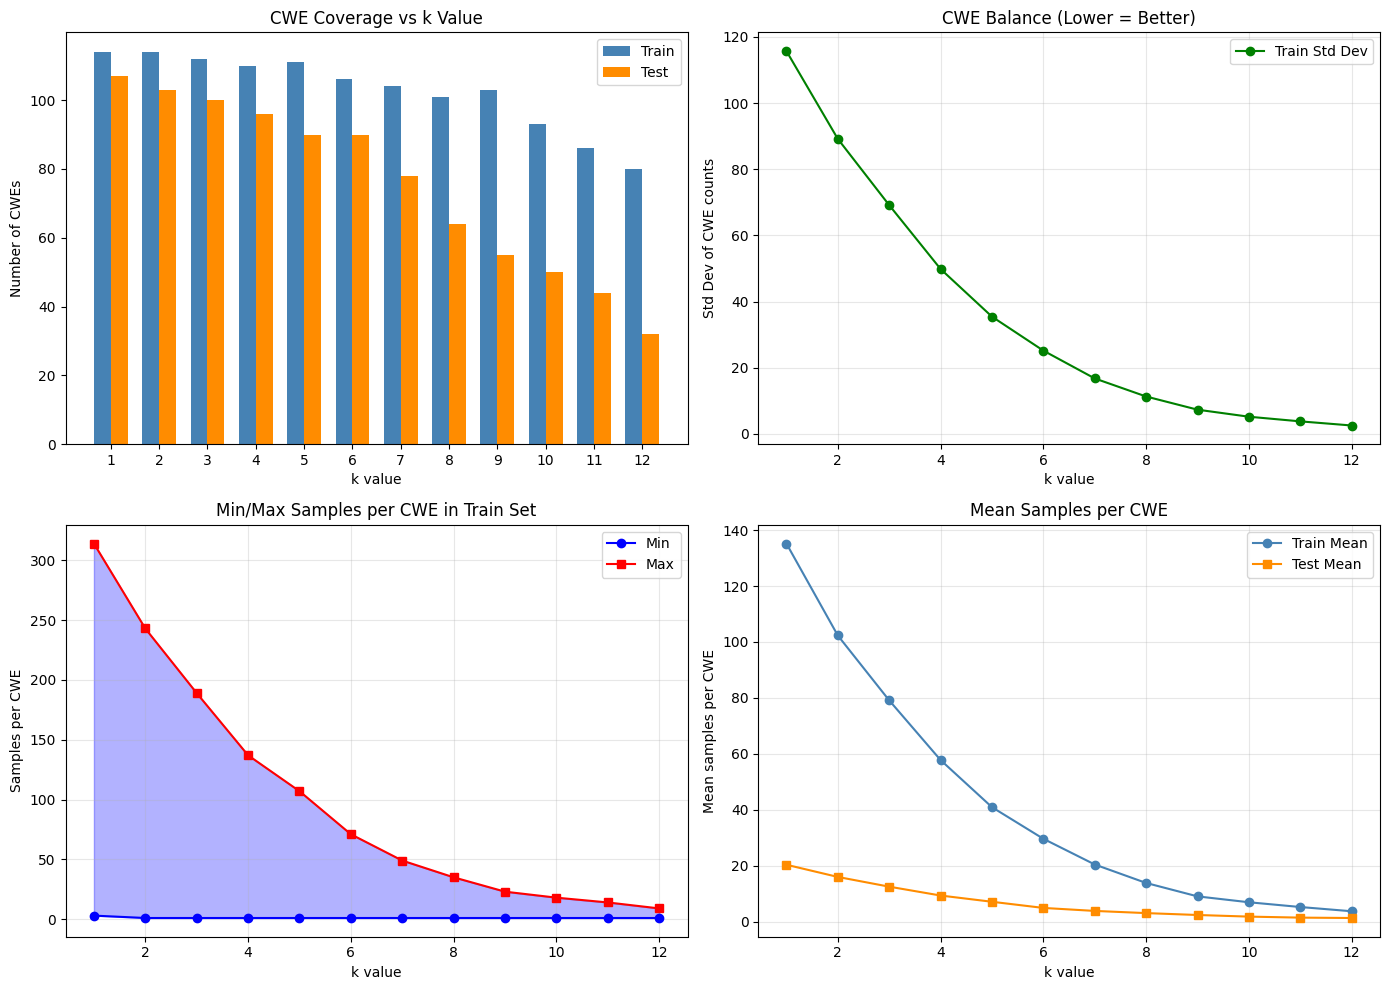


Plot saved to: /Users/aeg00011/Romeo/tensors/Experiment_5/cwe_analysis.png


In [13]:
# Visualize CWE coverage across k values
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

k_values = sorted(cwe_analysis.keys())

# Plot 1: Number of CWEs represented
ax1 = axes[0, 0]
train_cwes_count = [cwe_analysis[k]['num_cwes_train'] for k in k_values]
test_cwes_count = [cwe_analysis[k]['num_cwes_test'] for k in k_values]
x = np.arange(len(k_values))
width = 0.35
ax1.bar(x - width/2, train_cwes_count, width, label='Train', color='steelblue')
ax1.bar(x + width/2, test_cwes_count, width, label='Test', color='darkorange')
ax1.set_xlabel('k value')
ax1.set_ylabel('Number of CWEs')
ax1.set_title('CWE Coverage vs k Value')
ax1.set_xticks(x)
ax1.set_xticklabels(k_values)
ax1.legend()

# Plot 2: Standard deviation of CWE counts (lower = more balanced)
ax2 = axes[0, 1]
train_std = [cwe_analysis[k]['train_std'] for k in k_values]
ax2.plot(k_values, train_std, 'o-', color='green', label='Train Std Dev')
ax2.set_xlabel('k value')
ax2.set_ylabel('Std Dev of CWE counts')
ax2.set_title('CWE Balance (Lower = Better)')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot 3: Min and Max samples per CWE
ax3 = axes[1, 0]
train_min = [cwe_analysis[k]['train_min'] for k in k_values]
train_max = [cwe_analysis[k]['train_max'] for k in k_values]
ax3.fill_between(k_values, train_min, train_max, alpha=0.3, color='blue')
ax3.plot(k_values, train_min, 'o-', label='Min', color='blue')
ax3.plot(k_values, train_max, 's-', label='Max', color='red')
ax3.set_xlabel('k value')
ax3.set_ylabel('Samples per CWE')
ax3.set_title('Min/Max Samples per CWE in Train Set')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Mean samples per CWE
ax4 = axes[1, 1]
train_mean = [cwe_analysis[k]['train_mean'] for k in k_values]
test_mean = [cwe_analysis[k]['test_mean'] for k in k_values]
ax4.plot(k_values, train_mean, 'o-', label='Train Mean', color='steelblue')
ax4.plot(k_values, test_mean, 's-', label='Test Mean', color='darkorange')
ax4.set_xlabel('k value')
ax4.set_ylabel('Mean samples per CWE')
ax4.set_title('Mean Samples per CWE')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(EXPERIMENT_DIR, 'cwe_analysis.png'), dpi=150)
plt.show()

print(f"\nPlot saved to: {os.path.join(EXPERIMENT_DIR, 'cwe_analysis.png')}")

## 9. Compare Dataset Sizes Across k Values

In [14]:
# Create summary table
summary_data = []

for k in range(1, 13):
    if k not in juliet_results:
        continue
    result = juliet_results[k]
    summary_data.append({
        'k': k,
        'total_samples': result['total_samples'],
        'train_size': result['train_size'],
        'val_size': result['val_size'],
        'test_size': result['test_size'],
        'vulnerable': result['vulnerable'],
        'non_vulnerable': result['non_vulnerable'],
        'num_cwes': result['num_cwes']
    })

df_summary = pd.DataFrame(summary_data)

# Calculate retention percentage (compared to k=1)
if len(df_summary) > 0:
    k1_total = df_summary[df_summary['k'] == 1]['total_samples'].values[0]
    df_summary['retention_pct'] = (df_summary['total_samples'] / k1_total * 100).round(1)

print("Dataset Size Summary:")
print("="*100)
print(df_summary.to_string(index=False))

Dataset Size Summary:
 k  total_samples  train_size  val_size  test_size  vulnerable  non_vulnerable  num_cwes  retention_pct
 1          22015       15410      4425       2180       12185            9830       114          100.0
 2          16664       11664      3350       1650        9349            7315       114           75.7
 3          12660        8862      2544       1254        7108            5552       113           57.5
 4           9082        6357      1825        900        5048            4034       113           41.3
 5           6493        4545      1305        643        3623            2870       113           29.5
 6           4490        3143       902        445        2476            2014       110           20.4
 7           3041        2128       611        302        1680            1361       108           13.8
 8           2000        1400       402        198        1095             905       107            9.1
 9           1335         934       268   

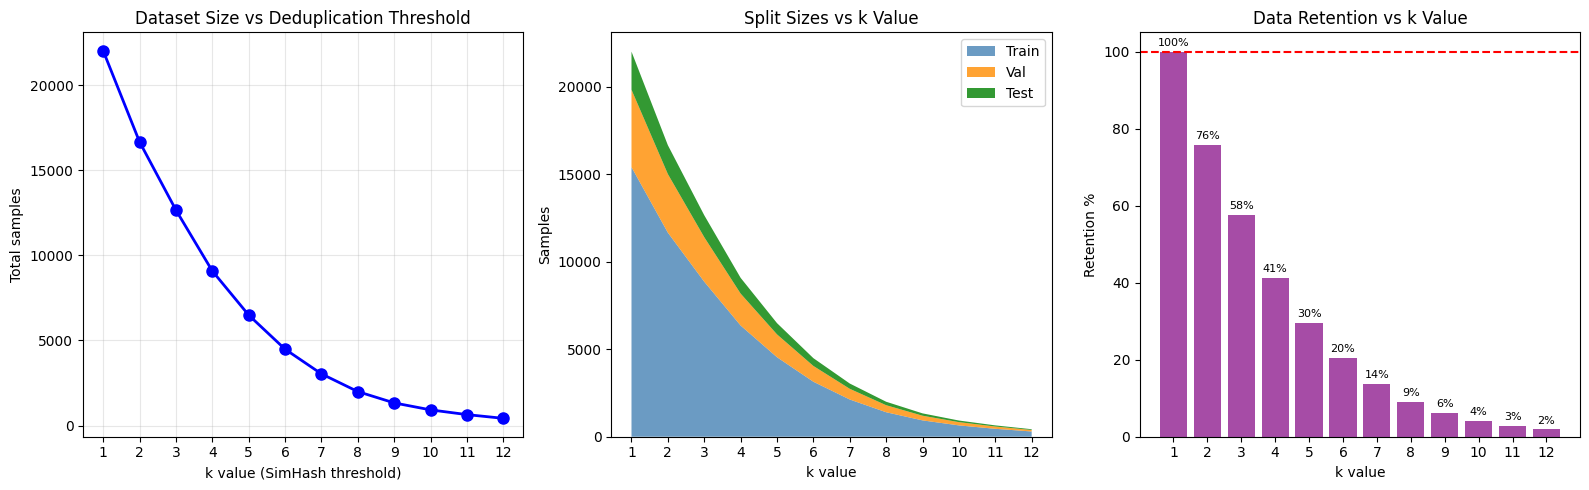


Plot saved to: /Users/aeg00011/Romeo/tensors/Experiment_5/dataset_sizes.png


In [15]:
# Visualize dataset sizes
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Total samples vs k
ax1 = axes[0]
ax1.plot(df_summary['k'], df_summary['total_samples'], 'o-', color='blue', linewidth=2, markersize=8)
ax1.set_xlabel('k value (SimHash threshold)')
ax1.set_ylabel('Total samples')
ax1.set_title('Dataset Size vs Deduplication Threshold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(df_summary['k'])

# Plot 2: Train/Val/Test sizes
ax2 = axes[1]
ax2.stackplot(df_summary['k'], 
              df_summary['train_size'], 
              df_summary['val_size'], 
              df_summary['test_size'],
              labels=['Train', 'Val', 'Test'],
              colors=['steelblue', 'darkorange', 'green'],
              alpha=0.8)
ax2.set_xlabel('k value')
ax2.set_ylabel('Samples')
ax2.set_title('Split Sizes vs k Value')
ax2.legend(loc='upper right')
ax2.set_xticks(df_summary['k'])

# Plot 3: Retention percentage
ax3 = axes[2]
bars = ax3.bar(df_summary['k'], df_summary['retention_pct'], color='purple', alpha=0.7)
ax3.axhline(y=100, color='r', linestyle='--', label='k=1 baseline')
ax3.set_xlabel('k value')
ax3.set_ylabel('Retention %')
ax3.set_title('Data Retention vs k Value')
ax3.set_xticks(df_summary['k'])
# Add percentage labels on bars
for bar, pct in zip(bars, df_summary['retention_pct']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{pct:.0f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(EXPERIMENT_DIR, 'dataset_sizes.png'), dpi=150)
plt.show()

print(f"\nPlot saved to: {os.path.join(EXPERIMENT_DIR, 'dataset_sizes.png')}")

## 10. Save Experiment Summary

In [16]:
#DEVIGN_CONFIG = None
#devign_result = None
# Compile all statistics into a single summary
experiment_summary = {
    'experiment_name': 'Experiment_5',
    'description': 'Deduplication experiment with CVE balancing for Juliet C (k=1-12) and class balancing for Devign. USING QWEN Tokenizer',
    'timestamp': datetime.datetime.now().isoformat(),
    'configuration': {
        'juliet_config': JULIET_CONFIG,
        'devign_config': DEVIGN_CONFIG,
        'devign_full_config': DEVIGN_FULL_CONFIG
    },
    'juliet_results': {},
    'devign_result': None,
    'devign_full_result': None,
    'cwe_analysis': {},
    'validation': {
        'total_datasets': len(created_datasets),
        'valid_datasets': sum(1 for r in validation_results if r['valid']),
        'errors': [r for r in validation_results if not r['valid']]
    }
}

# Add Juliet results (convert non-serializable types)
for k, result in juliet_results.items():
    experiment_summary['juliet_results'][f'k={k}'] = {
        'output_dir': result['output_dir'],
        'total_samples': result['total_samples'],
        'vulnerable': result['vulnerable'],
        'non_vulnerable': result['non_vulnerable'],
        'train_size': result['train_size'],
        'val_size': result['val_size'],
        'test_size': result['test_size'],
        'num_cwes': result['num_cwes'],
        'balance_cve': result['balance_cve'],
        'seed': result['seed']
    }

# Add Devign result (split version)
if devign_result:
    experiment_summary['devign_result'] = {
        'output_dir': devign_result['output_dir'],
        'total_samples': devign_result['total_samples'],
        'vulnerable': devign_result['vulnerable'],
        'non_vulnerable': devign_result['non_vulnerable'],
        'train_size': devign_result['train_size'],
        'val_size': devign_result['val_size'],
        'test_size': devign_result['test_size'],
        'positive_ratio': devign_result['vulnerable'] / devign_result['total_samples'],
        'negative_ratio': devign_result['non_vulnerable'] / devign_result['total_samples'],
        'balance_cve': devign_result['balance_cve'],
        'seed': devign_result['seed']
    }

# Add Devign full result (OOD evaluation set)
if devign_full_result:
    experiment_summary['devign_full_result'] = {
        'output_dir': devign_full_result['output_dir'],
        'total_samples': devign_full_result['total_samples'],
        'full_size': devign_full_result['full_size'],
        'vulnerable': devign_full_result['vulnerable'],
        'non_vulnerable': devign_full_result['non_vulnerable'],
        'positive_ratio': devign_full_result['vulnerable'] / devign_full_result['total_samples'],
        'negative_ratio': devign_full_result['non_vulnerable'] / devign_full_result['total_samples'],
        'balance_cve': devign_full_result['balance_cve'],
        'full_dataset_mode': devign_full_result['full_dataset_mode'],
        'seed': devign_full_result['seed']
    }

# Add CWE analysis
for k, analysis in cwe_analysis.items():
    experiment_summary['cwe_analysis'][f'k={k}'] = analysis

# Save to JSON
summary_path = os.path.join(EXPERIMENT_DIR, 'experiment_summary.json')
with open(summary_path, 'w') as f:
    json.dump(experiment_summary, f, indent=2)

print(f"Experiment summary saved to: {summary_path}")

# Also save the DataFrame as CSV
csv_path = os.path.join(EXPERIMENT_DIR, 'juliet_summary.csv')
df_summary.to_csv(csv_path, index=False)
print(f"CSV summary saved to: {csv_path}")

Experiment summary saved to: /Users/aeg00011/Romeo/tensors/Experiment_5/experiment_summary.json
CSV summary saved to: /Users/aeg00011/Romeo/tensors/Experiment_5/juliet_summary.csv


In [38]:
# Final summary
print("\n" + "="*80)
print("EXPERIMENT 1 COMPLETE")
print("="*80)

print(f"\nJuliet C SimHash Datasets (k=1 to k=12):")
print(f"  Successfully processed: {len(juliet_results)}/12")
print(f"  CVE balancing: ENABLED")
print(f"  Class balancing: ENABLED")

if devign_result:
    print(f"\nDevign Dataset (Split):")
    print(f"  Successfully processed: YES")
    print(f"  CVE balancing: DISABLED")
    print(f"  Class balancing: ENABLED")
    print(f"  Train/Val/Test: {devign_result['train_size']}/{devign_result['val_size']}/{devign_result['test_size']}")

if devign_full_result:
    print(f"\nDevign Dataset (Full - OOD Evaluation):")
    print(f"  Successfully processed: YES")
    print(f"  Full dataset mode: ENABLED")
    print(f"  Total samples: {devign_full_result['full_size']}")
    print(f"  Vulnerable/Non-vulnerable: {devign_full_result['vulnerable']}/{devign_full_result['non_vulnerable']}")

print(f"\nOutput Directory: {EXPERIMENT_DIR}")
print(f"Total Datasets: {len(created_datasets)}")
print(f"Validation: {sum(1 for r in validation_results if r['valid'])}/{len(validation_results)} passed")

print(f"\nFiles saved:")
print(f"  - experiment_summary.json")
print(f"  - juliet_summary.csv")
print(f"  - cwe_analysis.png")
print(f"  - dataset_sizes.png")
print(f"  - 14 dataset folders with tensors and metadata")
print(f"    - 12 Juliet C SimHash (k=1-12) with train/val/test splits")
print(f"    - 1 Devign with train/val/test splits")
print(f"    - 1 Devign OOD full dataset (full_sequences.pt, full_labels.pt)")

print(f"\n✓ Experiment completed at: {datetime.datetime.now().isoformat()}")


EXPERIMENT 1 COMPLETE

Juliet C SimHash Datasets (k=1 to k=12):
  Successfully processed: 12/12
  CVE balancing: ENABLED
  Class balancing: ENABLED

Devign Dataset (Split):
  Successfully processed: YES
  CVE balancing: DISABLED
  Class balancing: ENABLED
  Train/Val/Test: 16948/4866/2398

Devign Dataset (Full - OOD Evaluation):
  Successfully processed: YES
  Full dataset mode: ENABLED
  Total samples: 24212
  Vulnerable/Non-vulnerable: 12106/12106

Output Directory: /Users/aeg00011/Romeo/tensors/Experiment_3
Total Datasets: 14
Validation: 13/14 passed

Files saved:
  - experiment_summary.json
  - juliet_summary.csv
  - cwe_analysis.png
  - dataset_sizes.png
  - 14 dataset folders with tensors and metadata
    - 12 Juliet C SimHash (k=1-12) with train/val/test splits
    - 1 Devign with train/val/test splits
    - 1 Devign OOD full dataset (full_sequences.pt, full_labels.pt)

✓ Experiment completed at: 2026-01-19T15:12:50.236309
